In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/benroshan/factors-affecting-campus-placement/Placement_Data_Full_Class.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
df = df.rename(columns={"sl_no": "S.No.",
                        "ssc_p": "10th Percent",
                        "ssc_b": "10th Board",
                        "hsc_p": "12th Percent",
                        "hsc_b": "12th Board", 
                        "hsc_s": "12th Stream",
                        "degree_p": "Degree Percent",
                        "degree_t": "Degree",
                        "workex": "Experience",
                        "etest_p": "emp_test_percent",
                        "specialisation": "MBA Stream",
                        "mba_p": "MBA percent",})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S.No.             215 non-null    int64  
 1   gender            215 non-null    object 
 2   10th Percent      215 non-null    float64
 3   10th Board        215 non-null    object 
 4   12th Percent      215 non-null    float64
 5   12th Board        215 non-null    object 
 6   12th Stream       215 non-null    object 
 7   Degree Percent    215 non-null    float64
 8   Degree            215 non-null    object 
 9   Experience        215 non-null    object 
 10  emp_test_percent  215 non-null    float64
 11  MBA Stream        215 non-null    object 
 12  MBA percent       215 non-null    float64
 13  status            215 non-null    object 
 14  salary            148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [4]:
df.describe()

,S.No.,10th Percent,12th Percent,Degree Percent,emp_test_percent,MBA percent,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [5]:
temp = (df["status"] == "Placed").sum()
print(temp)

148


In [6]:
df["salary"].isna().sum()

np.int64(67)

In [7]:
df["placed"] = df["status"].map({"Placed": 1, "Not Placed": 0})
df["placed"].sum()

np.int64(148)

In [8]:
# Feature Engineering

# 1. Academic average
df["Academic Average"] = (
    df["10th Percent"] +
    df["12th Percent"] +
    df["Degree Percent"]
) / 3

# 2. 10th + 12th average
df["School Average"] = (
    df["10th Percent"] +
    df["12th Percent"]
) / 2

# 3. Degree + MBA average
df["Higher Education Average"] = (
    df["Degree Percent"] +
    df["MBA percent"]
) / 2

# 4. Overall academic performance
df["Overall Score"] = (
    df["10th Percent"] +
    df["12th Percent"] +
    df["Degree Percent"] +
    df["emp_test_percent"] +
    df["MBA percent"]
) / 5

# 5. Number of scores >= 70
df["High Score Count"] = (
    (df["10th Percent"] >= 70).astype(int) +
    (df["12th Percent"] >= 70).astype(int) +
    (df["Degree Percent"] >= 70).astype(int) +
    (df["emp_test_percent"] >= 70).astype(int) +
    (df["MBA percent"] >= 70).astype(int)
)

# 6. Work experience as binary
df["Experience Binary"] = df["Experience"].map({
    "Yes": 1,
    "No": 0
})

# 7. Degree performance compared with 10th
df["Degree - 10th"] = (
    df["Degree Percent"] - df["10th Percent"]
)

# 8. Degree performance compared with 12th
df["Degree - 12th"] = (
    df["Degree Percent"] - df["12th Percent"]
)

df.head()

,S.No.,gender,10th Percent,10th Board,12th Percent,12th Board,12th Stream,Degree Percent,Degree,Experience,...,salary,placed,Academic Average,School Average,Higher Education Average,Overall Score,High Score Count,Experience Binary,Degree - 10th,Degree - 12th
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,...,270000.0,1,72.000000,79.00,58.400,65.960,1,0,-9.00,-33.00
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,...,200000.0,1,78.380000,78.83,71.880,77.584,4,1,-1.85,-0.85
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,...,250000.0,1,65.666667,66.50,60.900,65.960,1,0,-1.00,-4.00
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,...,NaN,0,53.333333,54.00,55.715,57.086,0,0,-4.00,0.00
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,...,425000.0,1,77.566667,79.70,64.400,77.000,4,0,-12.50,-0.30


In [9]:
# Remove columns that should NOT be used for prediction

X = df.drop(columns=[
    "status",          # Target source
    "placed",          # Target
    "salary",          # Data leakage: salary is known after placement
    "S.No."            # ID column
])

y = df["placed"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['gender', '10th Percent', '10th Board', '12th Percent', '12th Board', '12th Stream', 'Degree Percent', 'Degree', 'Experience', 'emp_test_percent', 'MBA Stream', 'MBA percent', 'Academic Average', 'School Average', 'Higher Education Average', 'Overall Score', 'High Score Count', 'Experience Binary', 'Degree - 10th', 'Degree - 12th']

Target:
placed
1    148
0     67
Name: count, dtype: int64


In [10]:
#Encode Cat features
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)
X.head()

,10th Percent,12th Percent,Degree Percent,emp_test_percent,MBA percent,Academic Average,School Average,Higher Education Average,Overall Score,High Score Count,...,Degree - 12th,gender_M,10th Board_Others,12th Board_Others,12th Stream_Commerce,12th Stream_Science,Degree_Others,Degree_Sci&Tech,Experience_Yes,MBA Stream_Mkt&HR
0,67.00,91.00,58.00,55.0,58.80,72.000000,79.00,58.400,65.960,1,...,-33.00,True,True,True,True,False,False,True,False,True
1,79.33,78.33,77.48,86.5,66.28,78.380000,78.83,71.880,77.584,4,...,-0.85,True,False,True,False,True,False,True,True,False
2,65.00,68.00,64.00,75.0,57.80,65.666667,66.50,60.900,65.960,1,...,-4.00,True,False,False,False,False,False,False,False,False
3,56.00,52.00,52.00,66.0,59.43,53.333333,54.00,55.715,57.086,0,...,0.00,True,False,False,False,True,False,True,False,True
4,85.80,73.60,73.30,96.8,55.50,77.566667,79.70,64.400,77.000,4,...,-0.30,True,False,False,True,False,False,False,False,False


In [11]:
print("Number of features:", X.shape[1])
print(X.columns.tolist())

Number of features: 22
['10th Percent', '12th Percent', 'Degree Percent', 'emp_test_percent', 'MBA percent', 'Academic Average', 'School Average', 'Higher Education Average', 'Overall Score', 'High Score Count', 'Experience Binary', 'Degree - 10th', 'Degree - 12th', 'gender_M', '10th Board_Others', '12th Board_Others', '12th Stream_Commerce', '12th Stream_Science', 'Degree_Others', 'Degree_Sci&Tech', 'Experience_Yes', 'MBA Stream_Mkt&HR']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (172, 22)
Testing data: (43, 22)


In [13]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
placed
1    118
0     54
Name: count, dtype: int64

Testing set:
placed
1    30
0    13
Name: count, dtype: int64


In [14]:
#Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Logistic Regression** 

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression")
print("Accuracy %:", accuracy * 100)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
Accuracy %: 86.04651162790698
Precision: 0.9285714285714286
Recall   : 0.8666666666666667
F1 Score : 0.896551724137931
ROC-AUC  : 0.941025641025641

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        13
           1       0.93      0.87      0.90        30

    accuracy                           0.86        43
   macro avg       0.83      0.86      0.84        43
weighted avg       0.87      0.86      0.86        43



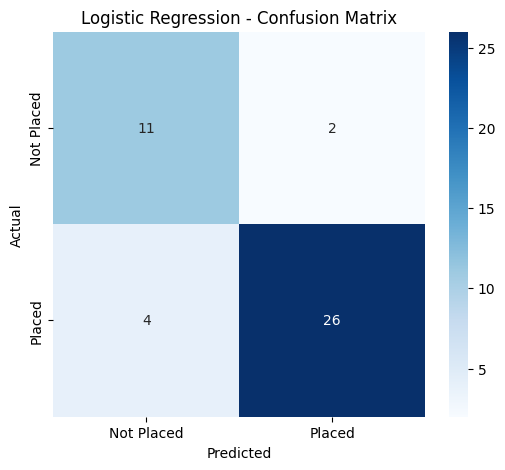

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# **Random Forest**

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [19]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("Accuracy %:", accuracy_rf * 100)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy %: 83.72093023255815
Precision: 0.8484848484848485
Recall   : 0.9333333333333333
F1 Score : 0.8888888888888888
ROC-AUC  : 0.9512820512820512

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.85      0.93      0.89        30

    accuracy                           0.84        43
   macro avg       0.82      0.77      0.79        43
weighted avg       0.83      0.84      0.83        43



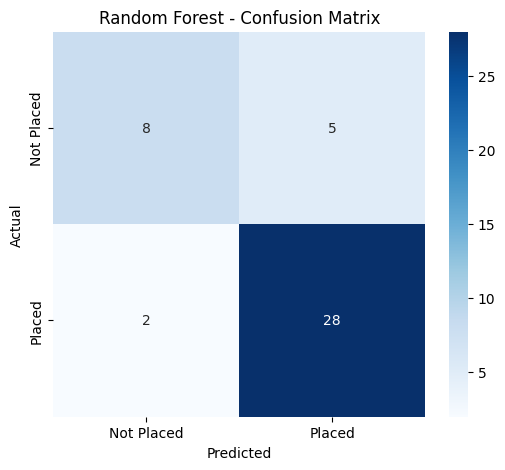

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# **Support Vector Machine (SVM)**

In [21]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [22]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Support Vector Machine")
print("Accuracy %:", accuracy_svm * 100)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)
print("ROC-AUC  :", roc_auc_svm)

Support Vector Machine
Accuracy %: 86.04651162790698
Precision: 0.9
Recall   : 0.9
F1 Score : 0.9
ROC-AUC  : 0.8897435897435897


# **Gradient Boosting**

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [24]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting")
print("Accuracy %:", accuracy_gb * 100)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)
print("ROC-AUC  :", roc_auc_gb)

Gradient Boosting
Accuracy %: 81.3953488372093
Precision: 0.8235294117647058
Recall   : 0.9333333333333333
F1 Score : 0.875
ROC-AUC  : 0.941025641025641


# **K-Nearest Neighbours (KNN)**

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print("K-Nearest Neighbors")
print("Accuracy %:", accuracy_knn * 100)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)
print("ROC-AUC  :", roc_auc_knn)

K-Nearest Neighbors
Accuracy %: 83.72093023255815
Precision: 0.8709677419354839
Recall   : 0.9
F1 Score : 0.8852459016393442
ROC-AUC  : 0.8769230769230768


# **Cross Validation of the 5- models**

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    print(name)
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std:", scores.std())
    print()

Logistic Regression
Fold Accuracies: [0.88571429 0.82857143 0.82352941 0.73529412 0.91176471]
Mean Accuracy: 0.8369747899159664
Std: 0.06092523905493976

Random Forest
Fold Accuracies: [0.82857143 0.85714286 0.82352941 0.67647059 0.85294118]
Mean Accuracy: 0.8077310924369747
Std: 0.0669308608292666

SVM
Fold Accuracies: [0.82857143 0.85714286 0.91176471 0.79411765 0.82352941]
Mean Accuracy: 0.8430252100840336
Std: 0.03976273107891758

Gradient Boosting
Fold Accuracies: [0.88571429 0.8        0.85294118 0.64705882 0.91176471]
Mean Accuracy: 0.8194957983193276
Std: 0.09394852752676554

KNN
Fold Accuracies: [0.82857143 0.91428571 0.79411765 0.79411765 0.91176471]
Mean Accuracy: 0.8485714285714285
Std: 0.054115037256347184



# **Hyperparameter Tuning**

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [29]:
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=cv,
    scoring="accuracy"
)

grid_knn.fit(X_train, y_train)

print("Best KNN Parameters:", grid_knn.best_params_)
print("Best KNN CV Accuracy:", grid_knn.best_score_ * 100)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best KNN CV Accuracy: 86.01680672268908


In [30]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=cv,
    scoring="accuracy"
)

grid_svm.fit(X_train, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)
print("Best SVM CV Accuracy:", grid_svm.best_score_ * 100)

Best SVM Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV Accuracy: 86.01680672268908


In [31]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring="accuracy"
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:", grid_rf.best_params_)
print("Best Random Forest CV Accuracy:", grid_rf.best_score_ * 100)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV Accuracy: 81.36134453781511


In [32]:
lr_params = {
    "C": [0.1, 1, 10, 100],
    "solver": ["liblinear"],
    "max_iter": [2000, 5000]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    lr_params,
    cv=cv,
    scoring="accuracy"
)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best Logistic Regression CV Accuracy:", grid_lr.best_score_ * 100)

Best Logistic Regression Parameters: {'C': 1, 'max_iter': 2000, 'solver': 'liblinear'}
Best Logistic Regression CV Accuracy: 87.21008403361346


In [33]:
gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=cv,
    scoring="accuracy"
)

grid_gb.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", grid_gb.best_params_)
print("Best Gradient Boosting CV Accuracy:", grid_gb.best_score_ * 100)

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best Gradient Boosting CV Accuracy: 83.69747899159664


# **Final Model Evaluation**
*Since Logistic Regression has the highest CV accuracy (87.21%)*

In [34]:
best_lr = grid_lr.best_estimator_

y_pred_final = best_lr.predict(X_test)
y_prob_final = best_lr.predict_proba(X_test)[:, 1]

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_prob_final)

print("Final Logistic Regression Model")
print("Accuracy %:", accuracy_final * 100)
print("Precision :", precision_final)
print("Recall    :", recall_final)
print("F1 Score  :", f1_final)
print("ROC-AUC   :", roc_auc_final)

Final Logistic Regression Model
Accuracy %: 83.72093023255815
Precision : 0.8709677419354839
Recall    : 0.9
F1 Score  : 0.8852459016393442
ROC-AUC   : 0.9333333333333333


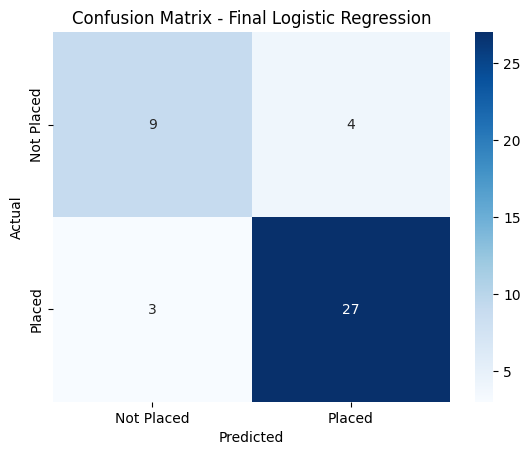

In [35]:
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Logistic Regression")
plt.show()

## ROC Curve - Final Logistic Regression

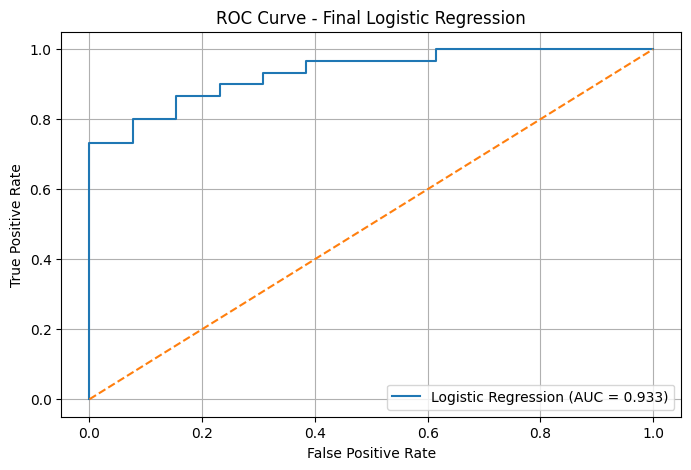

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression")
plt.legend()
plt.grid()
plt.show()

# **Final Model Comparison**

In [37]:
final_results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest",
        "Gradient Boosting"
    ],
    "CV Accuracy (%)": [
        grid_lr.best_score_ * 100,
        grid_knn.best_score_ * 100,
        grid_svm.best_score_ * 100,
        grid_rf.best_score_ * 100,
        grid_gb.best_score_ * 100
    ]
}

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="CV Accuracy (%)",
    ascending=False
)

final_results_df

,Model,CV Accuracy (%)
0,Logistic Regression,87.210084
1,KNN,86.016807
2,SVM,86.016807
4,Gradient Boosting,83.697479
3,Random Forest,81.361345


## Conclusion

After comparing the five machine learning models, Logistic Regression achieved the highest cross-validation accuracy of 87.21%.

The tuned Logistic Regression model was selected as the final model. On the test set, it achieved an accuracy of 83.72%, precision of 87.10%, recall of 90.00%, F1-score of 88.52%, and ROC-AUC of 93.33%.

The confusion matrix shows that the model correctly classified 36 out of 43 students. The ROC curve also indicates strong classification performance with an AUC of 0.933.

Overall, the model can effectively predict whether a student is likely to be placed based on the features used in the dataset.